---
title: "Transfer Learning" 
author: "B. Houghton"
---

## Code Demo

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

In [2]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Define CIFAR100 dataset, resize to 224x224 and normalize
transform = transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.Resize((224, 224)), 
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

test_transform = transforms.Compose(
        [
            transforms.Resize((224, 224)), 
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

trainset = torchvision.datasets.CIFAR100(root='/home/ben/data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='/home/ben/data', train=False, download=True, transform=test_transform)

# Define the data loaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# Loop over the data loader and print the first 10 images
for images, labels in trainloader:
    print(images.shape)
    break


Files already downloaded and verified
Files already downloaded and verified
torch.Size([64, 3, 224, 224])


In [4]:
# Number of images in the dataset
num_images = len(trainset)
print(f'Number of images in the dataset: {num_images}') 

# Number of batches in the dataloader
num_batches = len(trainloader)
print(f'Number of batches in the dataloader: {num_batches}')



Number of images in the dataset: 50000
Number of batches in the dataloader: 782


In [5]:
# Inspect a single image
image, label = next(iter(trainloader))
print(image.shape)
# Statistical properties
print('min:', image.min())
print('max:', image.max())
print('mean:', image.mean())
print('std:', image.std())
print('labels shape:', label.shape)
print('labels:', label)


torch.Size([64, 3, 224, 224])
min: tensor(-2.1179)
max: tensor(2.6400)
mean: tensor(-0.0975)
std: tensor(1.0845)
labels shape: torch.Size([64])
labels: tensor([32, 63, 72, 68, 55, 98, 16, 15,  8, 63, 95, 82, 69,  9, 44,  5, 48, 69,
        49, 75, 65, 81, 60, 14, 31, 26, 35, 29, 77, 82, 76, 80, 55, 60, 67, 48,
        42, 79, 70, 50, 63, 81, 66,  5, 13, 80, 92, 47, 48, 20, 74, 39, 10, 23,
        22, 19, 49, 97, 45, 71, 62, 90, 78, 13])


In [6]:
def unnormalize(tensor, mean, std):
    """
    Un-normalizes a tensor image with mean and standard deviation.
    Args:
        tensor (torch.Tensor): Tensor image of size (C, H, W)
        mean (sequence): Sequence of means for each channel
        std (sequence): Sequence of standard deviations for each channel
    """
    # Method 1: Using mul_ and add_ (in-place operations)
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

    # Method 2: Using the formula (not in-place)
    # tensor = tensor * torch.tensor(std).view(-1, 1, 1) + torch.tensor(mean).view(-1, 1, 1)
    # return tensor

# Example usage for CIFAR-100:
# cifar_mean = [0.5071, 0.4867, 0.4408]
# cifar_std = [0.2675, 0.2565, 0.2761]

cifar_mean = [0.485, 0.456, 0.406]
cifar_std = [0.229, 0.224, 0.225]

# # For a batch of images
# unnormalized_images = unnormalize(images.clone(), cifar_mean, cifar_std)

# For a single image
unnormalized_image = unnormalize(image[0].clone(), cifar_mean, cifar_std)

# inspect the unnormalized image
print(unnormalized_image.shape)
print(unnormalized_image.min())
print(unnormalized_image.max())
print(unnormalized_image.mean())
print(unnormalized_image.std())


torch.Size([3, 224, 224])
tensor(0.)
tensor(1.)
tensor(0.5586)
tensor(0.2807)


In [7]:
# Get CIFAR100 class names
class_names = trainset.classes
print(class_names)

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

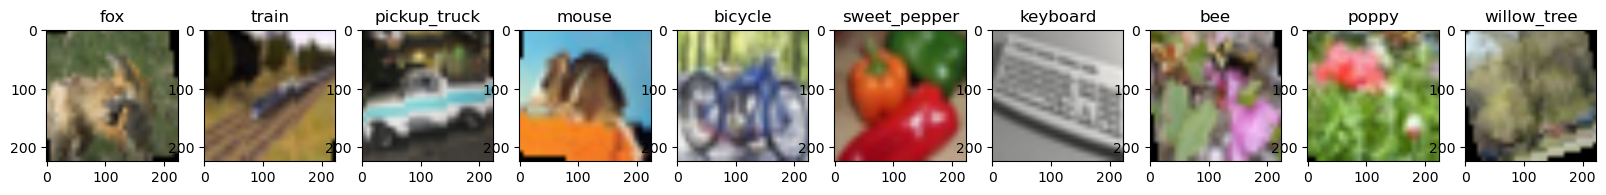

In [8]:
# Define a function to plot the first 10 images
def plot_images(images, labels):
    plt.figure(figsize=(20, 10))
    for i in range(10):
        # add label to the image
        plt.subplot(1, 10, i+1)
        unnormalized_image = unnormalize(images[i], cifar_mean, cifar_std)
        plt.imshow(unnormalized_image.permute(1, 2, 0))
        plt.title(class_names[labels[i]])
    plt.show()

# Loop over the data loader and print the first 10 images
for images, labels in trainloader:
    # plot the first 10 images in a grid
    plot_images(images[:10], labels[:10])
    break


In [9]:
# Define a function to get a resnet model
def get_resnet():
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Freeze the layers which you don't want to train
    for param in resnet.parameters():
        param.requires_grad = False
    # Replace the last fully connected layer with a new one
    resnet.fc = nn.Linear(resnet.fc.in_features, 100)
    return resnet

model = get_resnet()
model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [10]:
# A function to plot training and validation loss and accuracy
from IPython import display

def plot_training(train_loss, test_loss, train_acc, test_acc):
    fig = plt.figure(1, figsize=(12, 6))
    plt.clf()

    ax1 = fig.add_subplot(1, 2, 1) # (Rows, Columns, Position)
    ax2 = fig.add_subplot(1, 2, 2) # (Rows, Columns, Position)
    epochs = [int(i+1) for i in range(len(train_loss))]

    ax1.set_title('Training and Testing Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Average Loss (Categorical Cross Entropy)')
    ax1.plot(epochs, train_loss, label='Train Loss', marker='o', linestyle=':')
    ax1.plot(epochs, test_loss, label='Test Loss', marker='o', linestyle=':')
    ax1.legend()

    ax2.set_title('Training and Testing Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.plot(epochs, train_acc, label='Train Acc', marker='o', linestyle=':')
    ax2.plot(epochs, test_acc, label='Test Acc', marker='o', linestyle=':')
    ax2.legend()
    
    display.display(plt.gcf())
    display.clear_output(wait=True)


In [11]:
loss = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.1,
    patience=3,
    verbose=True
)

/home/ben/miniconda3/envs/torch/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [12]:
# define a function to train and plot training progress
def train_and_plot(model, trainloader, testloader, criterion, optimizer, num_epochs=10):
    
    train_loss = []
    test_loss = []
    train_acc = []
    test_acc = []
    
    for epoch in range(num_epochs):

        # place model in training mode
        model.train()
        total = 0
        correct = 0
        avg_loss = 0
        # Loop over the training data
        for i, (images, labels) in enumerate(trainloader):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            avg_loss = (avg_loss * i + loss.item()) / (i + 1)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Send the loss and accuracy to the cpu

        train_acc.append(100 * correct / total)
        train_loss.append(avg_loss)

        # Evaluate the model on the test set
        model.eval()
        with torch.no_grad():
            total = 0
            correct = 0
            avg_loss = 0
            for i, (images, labels) in enumerate(testloader):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                avg_loss = (avg_loss * i + loss.item()) / (i + 1)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            test_loss.append(avg_loss)
            test_acc.append(100 * correct / total)

            # Step the scheduler based on validation loss
            scheduler.step(avg_loss)  # For ReduceLROnPlateau

        # Plot the training and validation loss and accuracy
        plot_training(train_loss, test_loss, train_acc, test_acc)


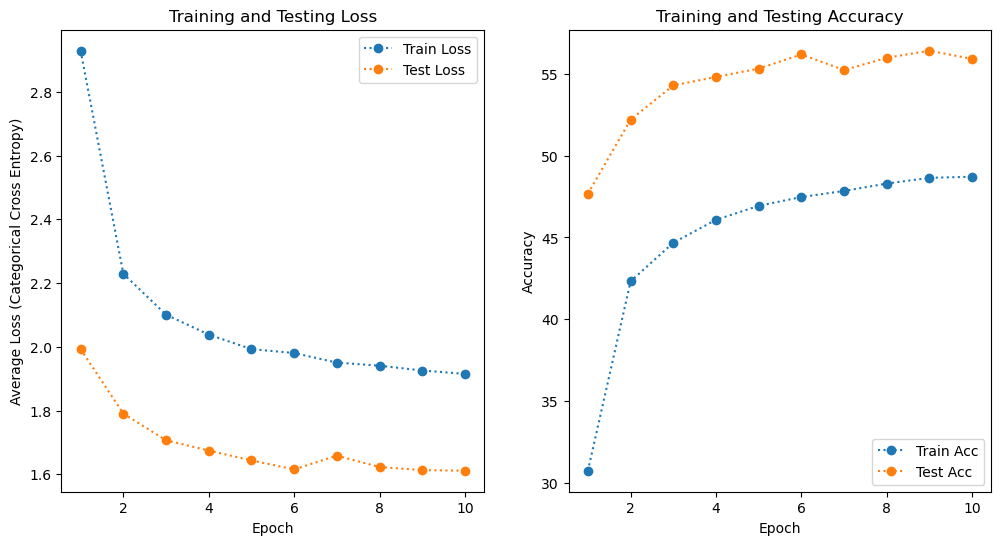

In [13]:
train_and_plot(model, trainloader, testloader, loss, optimizer, num_epochs=10)